Topics to Cover:
- Supervised vs Unsupervised vs Reinforcement Learning
- Training, validation, and test sets
- Overfitting and underfitting
- Bias-variance tradeoff
- Cross-validation techniques
- Performance metrics (accuracy, precision, recall, F1, ROC-AUC)

Hands-on Exercise:
- Implement train-test split manually
- Create visualizations showing overfitting vs underfitting
- Compare different cross-validation strategies

## Machine Learning Lifecycle

<pre>
     Problem Definition
            ↓
      Data Collection
            ↓
Exploratory Data Analysis (EDA)
            ↓
Feature Engineering & Selection
            ↓
      Model Selection
            ↓
      Model Training
            ↓
Model Evaluation and Training
            ↓
     Model Deployment
            ↓
Model Monitoring & Maintainance
</pre>

### Train-Test Split

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
import torch
import pandas as pd

In [2]:
data = fetch_california_housing(as_frame=True)

df = data.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
import torch

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(X_train)

tensor([[-0.3262,  0.3485, -0.1749,  ...,  0.0514, -1.3728,  1.2726],
        [-0.0358,  1.6181, -0.4028,  ..., -0.1174, -0.8767,  0.7092],
        [ 0.1447, -1.9527,  0.0882,  ..., -0.0323, -0.4601, -0.4476],
        ...,
        [-0.4970,  0.5865, -0.6068,  ...,  0.0203, -0.7550,  0.5995],
        [ 0.9655, -1.0798,  0.4022,  ...,  0.0071,  0.9065, -1.1855],
        [-0.6854,  1.8562, -0.8514,  ..., -0.0854,  0.9954, -1.4149]])


In [59]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [60]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)


In [61]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [62]:
train_losses = []
test_losses = []

epochs = 20

for epoch in range(epochs):
    
    #Training
    model.train()
    epoch_train_loss = 0
    
    for xb, yb in train_loader:
        preds = model(xb)
        loss = loss_fn(preds, yb)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        epoch_train_loss += loss.item()
        
    epoch_train_loss /= len(train_loader)   # calculate avg loss per batch
    train_losses.append(epoch_train_loss)
    
    #Testing
    model.eval()
    epoch_val_loss = 0
    
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = model(xb)
            loss = loss_fn(preds, yb)
            epoch_val_loss += loss.item()
            
        epoch_val_loss /= len(test_loader)
        test_losses.append(epoch_val_loss)
        
    print(
        f"Epoch: {epoch:02d} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Test Loss: {epoch_val_loss:.4f}"
    )

Epoch: 00 | Train Loss: 1.4079 | Test Loss: 0.6156
Epoch: 01 | Train Loss: 0.4960 | Test Loss: 0.4481
Epoch: 02 | Train Loss: 0.4139 | Test Loss: 0.4162
Epoch: 03 | Train Loss: 0.3929 | Test Loss: 0.4047
Epoch: 04 | Train Loss: 0.3812 | Test Loss: 0.3899
Epoch: 05 | Train Loss: 0.3702 | Test Loss: 0.3763
Epoch: 06 | Train Loss: 0.3597 | Test Loss: 0.3726
Epoch: 07 | Train Loss: 0.3493 | Test Loss: 0.3564
Epoch: 08 | Train Loss: 0.3441 | Test Loss: 0.3783
Epoch: 09 | Train Loss: 0.3370 | Test Loss: 0.3439
Epoch: 10 | Train Loss: 0.3275 | Test Loss: 0.3416
Epoch: 11 | Train Loss: 0.3228 | Test Loss: 0.3485
Epoch: 12 | Train Loss: 0.3192 | Test Loss: 0.3293
Epoch: 13 | Train Loss: 0.3116 | Test Loss: 0.3239
Epoch: 14 | Train Loss: 0.3080 | Test Loss: 0.3211
Epoch: 15 | Train Loss: 0.3124 | Test Loss: 0.3142
Epoch: 16 | Train Loss: 0.3013 | Test Loss: 0.3122
Epoch: 17 | Train Loss: 0.2995 | Test Loss: 0.3153
Epoch: 18 | Train Loss: 0.2957 | Test Loss: 0.3296
Epoch: 19 | Train Loss: 0.2960 

### Overfitting vs Underfitting

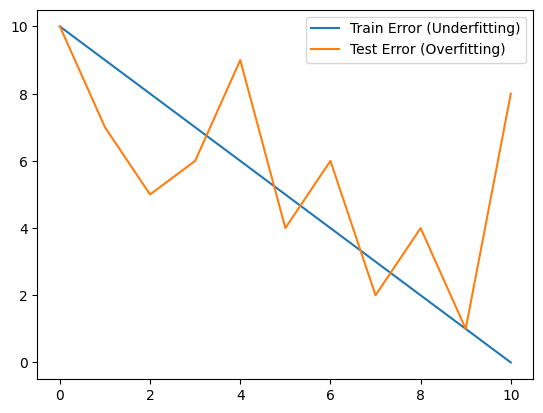

In [71]:
import matplotlib.pyplot as plt

x = [0,1,2,3,4,5,6,7,8,9,10]

train_error = [10,9,8,7,6,5,4,3,2,1,0]
test_error = [10,7,5,6,9,4,6,2,4,1,8]

plt.plot(x, train_error, label="Train Error (Underfitting)")
plt.plot(x, test_error, label="Test Error (Overfitting)")

plt.legend()

plt.show()

In [73]:
import seaborn as sns

df = sns.load_dataset("tips")

X = df[["total_bill"]]
y = df["smoker"]


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)


from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print(scores)

[0.63265306 0.63265306 0.6122449  0.6122449  0.5625    ]
